<a href="https://colab.research.google.com/github/ayoushbirjani4-spec/fiyrank-firstlab/blob/main/work/notebooks/w01_research_question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ayoushbirjani4-spec/fiyrank-firstlab/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [24]:
!git clone https://github.com/ayoushbirjani4-spec/fiyrank-firstlab.git
%cd fiyrank-firstlab

Cloning into 'fiyrank-firstlab'...
remote: Enumerating objects: 116, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 116 (delta 32), reused 94 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (116/116), 1.85 MiB | 8.15 MiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/fiyrank-firstlab/fiyrank-firstlab


## 1. My lane (or freestyle) and why

**Lane: Content Refresh Prioritization.** Pages decay in search rank at different rates, and reviewing every page for a possible refresh is a full-time job for no one. My Week 1 discovery work showed content_age and trend_direction aren't independent — older, declining content clusters in ways a hand-rule could miss. This lane asks: can a model rank which pages to review first, better than a simple age-based rule?

In [25]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Placeholder for code related to 'Content Refresh Prioritization'.
# For example, you might consider how to define 'content_age' or 'trend_direction'.
# Or, if you have access to a small sample dataset, you could load it here.
# print("Initial thought: Define metrics for 'content_age' and 'trend_direction'")

## 2. The question: decision, action, cost of a wrong call

**The decision:** which pages an SEO content team reviews and refreshes this sprint, out of thousands.

**The actor:** a content strategist working off a prioritized queue, not an engineer.

**Cost of a false positive:** wasted review hours on a page that wasn't actually declining.

**Cost of a false negative:** a genuinely declining page skipped, continuing to lose search visibility and traffic uncorrected for another cycle.

In [26]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Placeholder for code related to the cost of a wrong call.
# For example, you might define some hypothetical values to estimate costs:
# review_hour_cost = 50  # dollars
# lost_traffic_value_per_day = 100 # dollars
# print(f"Estimated cost of a false positive: ${review_hour_cost} per wasted review hour.")
# print(f"Estimated cost of a false negative: ${lost_traffic_value_per_day} per day of lost traffic.")

## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

In [27]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import pandas as pd
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print(f"Total pages: {len(df)}")
print(f"Declining pages (trend_direction == 'down'): {(df['trend_direction'] == 'down').mean():.1%}")
print(df.groupby('trend_direction')['content_age_days'].median())

print("\n--- DataFrame Info ---\n")
df.info()

print("\n--- DataFrame Description ---\n")
df.describe()

Total pages: 30000
Declining pages (trend_direction == 'down'): 54.2%
trend_direction
down      216.0
flat      231.0
new       279.0
stable    300.0
up        291.5
Name: content_age_days, dtype: float64

--- DataFrame Info ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              30000 non-null  object 
 1   client_id               30000 non-null  object 
 2   search_volume           27532 non-null  float64
 3   competition             27532 non-null  float64
 4   competition_level       27390 non-null  object 
 5   cpc                     27532 non-null  float64
 6   content_type            30000 non-null  object 
 7   main_intent             27626 non-null  object 
 8   word_count              22301 non-null  float64
 9   char_count              22301 non-null  float64
 10  provider_used       

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,sessions_prev_30d,content_age_days,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct
count,27532.000000,27532.000000,27532.000000,22301.000000,22301.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.00000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000,29875.000000,30000.000000,26612.000000
mean,158.882391,0.146954,0.485342,3107.760325,20665.277835,5200.366300,16.097333,49.942467,37.066633,35.937700,...,10.283000,256.16780,4.786533,46.098300,0.510733,16.34238,2.534520,18.212921,0.768196,-4.785969
std,1518.270825,0.285241,2.101560,1452.382598,10115.344042,16838.019547,75.076958,152.101430,107.069131,103.748185,...,42.578003,132.70793,0.790392,42.078709,3.279162,15.21679,8.310096,29.472768,7.429454,473.861780
min,0.000000,0.000000,0.000000,8.000000,40.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,90.00000,3.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,-100.000000
25%,0.000000,0.000000,0.000000,2413.000000,15644.000000,81.000000,0.000000,2.000000,2.000000,2.000000,...,1.000000,132.00000,4.000000,20.000000,0.000000,6.20000,0.000000,0.000000,0.000000,-62.600000
50%,10.000000,0.000000,0.000000,2877.000000,19116.000000,731.000000,1.000000,8.000000,7.000000,7.000000,...,2.000000,236.00000,5.000000,20.000000,0.070000,10.80000,0.000000,5.000000,0.000000,-33.500000
75%,20.000000,0.130000,0.000000,3666.000000,24011.000000,3615.250000,7.000000,33.000000,27.000000,27.000000,...,7.000000,333.00000,5.000000,104.000000,0.290000,22.30000,1.350000,23.530000,0.000000,0.000000
max,74000.000000,1.000000,100.360000,9546.000000,111158.000000,517715.000000,4178.000000,5998.000000,4345.000000,4913.000000,...,4247.000000,564.00000,6.000000,373.000000,100.000000,245.00000,100.000000,300.000000,300.000000,44900.000000


## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*
This work can say what pages show a declining engagement pattern over the last 90 days, based on trend_direction and the related session/impression metrics — that's observed, directly in the data. It can also say that content age, word count, and content type correlate with decline status in this sample — that's directional, not causal. One result already complicates my own starting assumption: I expected older content to decline more, but the median age of declining pages (216 days) is actually lower than stable or growing pages (300 and 291.5 days). I'm not dropping the lane over this, but I'm not going to pretend my Week 1 hypothesis held up cleanly either — it didn't, and I'd rather say that upfront than have a reviewer catch it later. What this work can eventually produce is a ranked queue of pages worth a human reviewing first — decision-support, not a verdict.

What it can't say: it can't say anything caused a page to decline — there's no experimental design here, only correlation in one anonymized snapshot. It can't explain why a page is declining, because there's no query-level or content-text data in this dataset to diagnose that. It says nothing about how Google's algorithm works — this is FlyRank's own analytics, not search engine internals. The 54.2% "down" rate is this sample's rate, not a claim about how much content decays in general — I don't know if that split was engineered for teaching purposes, so I won't generalize it. And any claim touching search_volume, word_count, or provider_used has to be read as applying to a biased subset of pages, not all 30,000 — those columns are missing on anywhere from 8% to 71% of rows.




In [28]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


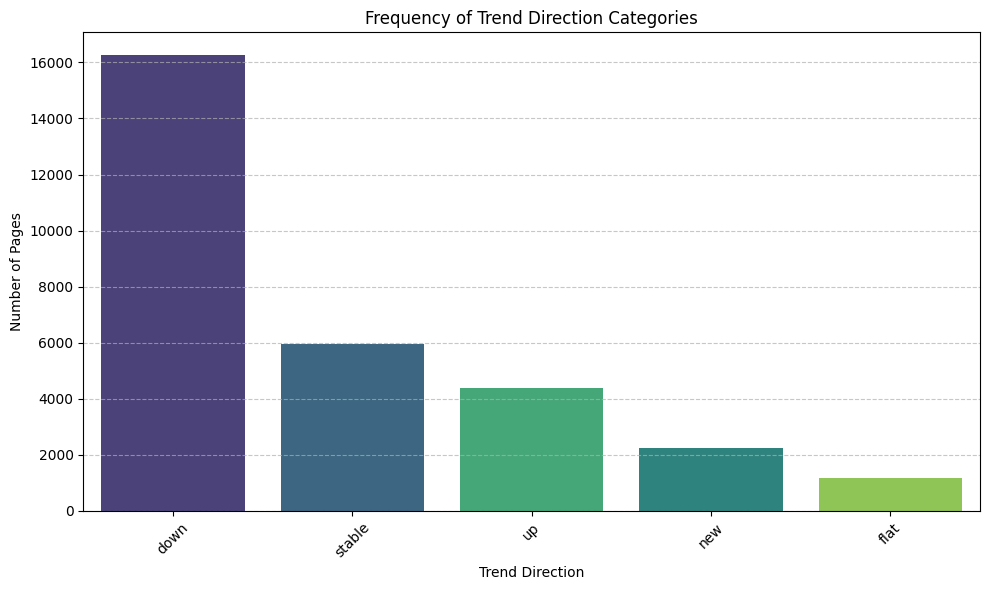

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart for 'trend_direction' frequency
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='trend_direction', hue='trend_direction', palette='viridis', order=df['trend_direction'].value_counts().index, legend=False)
plt.title('Frequency of Trend Direction Categories')
plt.xlabel('Trend Direction')
plt.ylabel('Number of Pages')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.